### Làm quen với các phép toán trong python

In [ ]:
%pip install numpy matplotlib

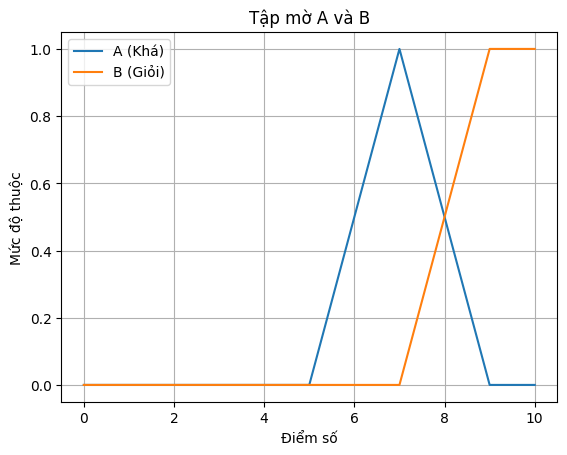

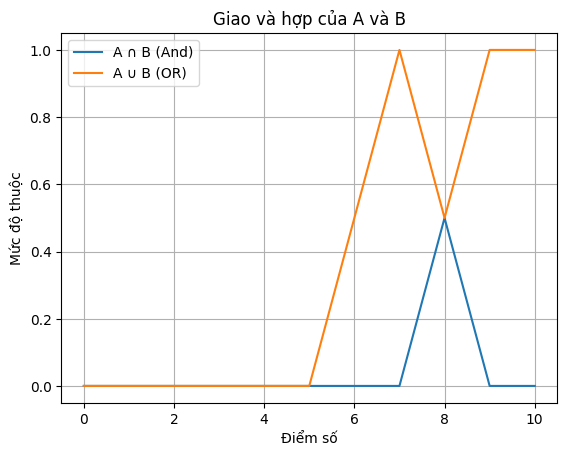

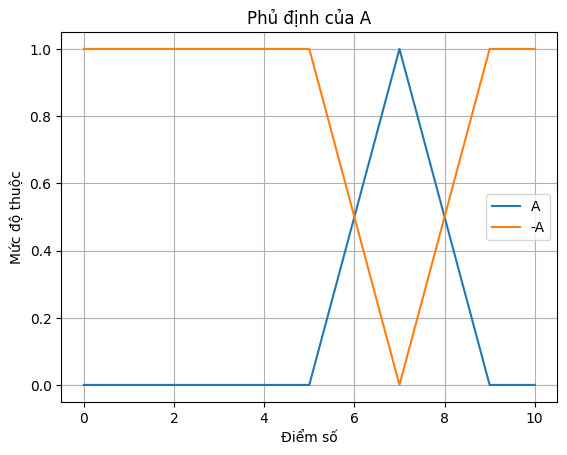

Sai số tối đa của De Morgan 1:  0.0
Sai sỐ tối đa của De Morgan 2:  0.0


In [6]:
import numpy as np
import matplotlib.pyplot as plt 

# 1. Không gian nền X: điểm số từ 0 đén 10
x = np.linspace (0, 10, 1001) #np.linspace tạo ra một mảng 1 chiều có 1001 phần tử từ 0 đến 10

# 2. Định nghĩa hàm thuộc cho A: "Khá"
def mu_A(x): # hàm này nhận một giá trị x và trả về giá trị thuộc của x đối với tập A
    x = np.asarray(x)  # chuyển x thành một mảng numpy 
    mu = np.zeros_like(x) # tạo một mảng mu có cùng kích thước với x, ban đầu chứa toàn số 0
    # đoạn 5-7: tăng tuyến tính từ 0  đến 1
    mask1 = (x >= 5) & (x < 7) # tạo một mặt nạ để xác định các phần tử của x nằm trong khoảng từ 5 đến 7
    mu[mask1] = (x[mask1] - 5) /2.0 # tính giá trị của mu cho các phần tử của x nằm trong khoảng từ 5 đến 7
    # đoạn 7-9: giảm tuyến tính từ 1 đến 0 
    mask2 = (x >= 7) & (x < 9) # tạo một mặt nạ để xác định các phần tử của x nằm trong khoảng từ 7 đến 9
    mu[mask2] = (9 - x[mask2]) / 2.0 # tính giá trị của mu cho các phần tử của x nằm trong khoảng từ 7 đến 9
    return mu

# 3. Định nghĩa hàm thuộc cho B: "Giỏi"
def mu_B(x): # hàm này nhận một giá trị x và trả về giá trị thuộc của x đối với tập B
    x = np.asarray(x) # chuyển x thành một mảng numpy
    mu = np.zeros_like(x) # tạo một mảng mu có cùng kích thước với x, ban đầu chứa toàn số 0
    # đoạn 7-9: tăng tuyến tính từ 0 đến 1
    mask1 = (x >= 7) & (x < 9) # tạo một mặt nạ để xác định các phần tử của x nằm trong khoảng từ 7 đến 9
    mu[mask1] = (x[mask1] - 7) / 2.0 # tính giá trị của mu cho các phần tử của x nằm trong khoảng từ 7 đến 9
    # từ 9 trở lên: 1
    mask2 = (x >= 9) # tạo một mặt nạ để xác định các phần tử của x lớn hơn hoặc bằng 9
    mu[mask2] = 1.0 # gán giá trị 1 cho các phần tử của x lớn hơn hoặc bằng 9
    return mu 
A = mu_A(x) # tính giá trị thuộc của x đối với tập A
B = mu_B(x) # tính giá trị thuộc của x đối với tập B

# Phép toán trong tập mờ
A_and_B =  np.minimum(A, B) # phép AND: lấy giá trị nhỏ hơn giữa A và B
A_or_B = np.maximum(A, B) # phép OR: lấy giá trị lớn hơn giữa A và B
not_A =  1 - A # Phủ định A
not_B =  1 -  B # Phủ định B

# 5.Vẽ hàm thuộc ban đầu A, B

plt.figure() # tạo một hình mới để vẽ đồ thị
plt.plot(x, A, label='A (Khá)') # vẽ đồ thị của A
plt.plot(x, B, label="B (Giỏi)") # vẽ đồ thị của B
plt.title("Tập mờ A và B") # đặt tiêu đề cho đồ thị
plt.xlabel("Điểm số") # đặt nhãn cho trục x
plt.ylabel("Mức độ thuộc") # đặt nhãn cho trục y
plt.legend() # hiển thị chú thích
plt.grid() # hiển thị lưới
plt.show() # hiển thị đồ thị

# 6. Vẽ giao A∩B và hợp A∪B

plt.figure() # tạo một hình mới để vẽ đồ thị
plt.plot(x, A_and_B, label="A ∩ B (And)") # vẽ đồ thị của A AND B
plt.plot(x, A_or_B, label="A ∪ B (OR)") # vẽ đồ thị của A OR B
plt.title("Giao và hợp của A và B") # đặt tiêu đề cho đồ thị
plt.xlabel("Điểm số") # đặt nhãn cho trục x
plt.ylabel("Mức độ thuộc") # đặt nhãn cho trục y
plt.legend() # hiển thị chú thích
plt.grid() # hiển thị lưới
plt.show() # hiển thị đồ thị

# 7. Vẽ phủ định của A

plt.figure() # tạo một hình mới để vẽ đồ thị
plt.plot(x, A, label="A") # vẽ đồ thị của A
plt.plot(x, not_A, label="-A") # vẽ đồ thị của phủ định A
plt.title("Phủ định của A") # đặt tiêu đề cho đồ thị
plt.xlabel("Điểm số") # đặt nhãn cho trục x
plt.ylabel("Mức độ thuộc") # đặt nhãn cho trục y
plt.legend() # hiển thị chú thích
plt.grid() # hiển thị lưới
plt.show() # hiển thị đồ thị

# 8. Kiểm tra luật De Morgan: ¬(A ∪ B) = ¬A ∩ ¬B
left = 1 - A_or_B # tính phủ định của A OR B
right = np.minimum(not_A, not_B) # tính A AND B

print("Sai số tối đa của De Morgan 1: ", np.max(np.abs(left - right))) # in ra sai số tối đa giữa hai bên của luật De Morgan

# 9.Kiểm tra luật De Morgan 2: ¬(A ∩ B) = ¬A ∪ ¬B
left2 = 1 - A_and_B # tính phủ định của A AND B
right2 =  np.maximum(not_A, not_B) # tính A OR B
print("Sai sỐ tối đa của De Morgan 2: ", np.max(np.abs(left2 - right2))) # in ra sai số tối đa giữa hai bên của luật De Morgan


# End 